# 02 - Fine-tune VideoMAE-Small On Olympic AI2025

Read metadata from Google Drive, train VideoMAE-Small, save periodic checkpoints, and write the best model bundle back to Drive.


In [1]:
# ============================================================
# CONFIG - Drive paths must match notebook 01
# ============================================================
PROJECT_ROOT = "/content/drive/MyDrive/vsl-recognition"
METADATA_DIR = f"{PROJECT_ROOT}/metadata"
CHECKPOINT_DIR = f"{PROJECT_ROOT}/checkpoints/videomae_olympic"
MODEL_DIR = f"{PROJECT_ROOT}/models/videomae_olympic_best"
LAST_CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/last_checkpoint.pt"

MODEL_NAME = "MCG-NJU/videomae-small-finetuned-kinetics"
NUM_FRAMES = 16  # justify from notebook 01: frame-count coverage for 16 vs 8/24/32
IMAGE_SIZE = 224  # justify from notebook 01 resolution/aspect-ratio EDA + pretrained VideoMAE input

BATCH_SIZE = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
EPOCHS = 30
WARMUP_EPOCHS = 5
LABEL_SMOOTHING = 0.1
FP16 = True
NUM_WORKERS = 2
USE_WEIGHTED_SAMPLER = True  # justify from notebook 01 long-tail/head-body-tail class imbalance
CROP_SCALE = (0.85, 1.0)
CROP_RATIO = (0.9, 1.1)
COLOR_JITTER_RANGE = (0.9, 1.1)
SPEED_AUGMENT_RANGE = None  # e.g. (0.9, 1.1) only if duration/FPS EDA supports it
FILTER_BAD_FRAMES = True  # remove blank/solid frames before uniform sampling; motivated by notebook 01 bad-frame EDA
MIN_VALID_FRAMES = 8  # if filtering leaves fewer frames, fall back to original frames instead of dropping the video
SEED = 42
SAVE_EVERY = 5
AUTO_RESUME = True


## 1. Setup


In [2]:
import os
import sys
import json
import random
import time
from pathlib import Path
from collections import Counter

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    !pip install -q transformers accelerate decord opencv-python-headless scikit-learn tqdm safetensors

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import CenterCrop, ColorJitter, Normalize, RandomResizedCrop, Resize
from torchvision.transforms.functional import adjust_brightness, adjust_contrast, adjust_saturation
from transformers import AutoImageProcessor, VideoMAEForVideoClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_DIR:", METADATA_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("LAST_CHECKPOINT_PATH:", LAST_CHECKPOINT_PATH)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 48.5 MB/s eta 0:00:00
Device: cpu
PROJECT_ROOT: /content/drive/MyDrive/vsl-recognition
METADATA_DIR: /content/drive/MyDrive/vsl-recognition/metadata
CHECKPOINT_DIR: /content/drive/MyDrive/vsl-recognition/checkpoints/videomae_olympic
MODEL_DIR: /content/drive/MyDrive/vsl-recognition/models/videomae_olympic_best
LAST_CHECKPOINT_PATH: /content/drive/MyDrive/vsl-recognition/checkpoints/videomae_olympic/last_checkpoint.pt


## 2. Load Metadata And DataLoaders


In [3]:
metadata_dir = Path(METADATA_DIR)
with open(metadata_dir / "train.json", encoding="utf-8") as f:
    train_data = json.load(f)
with open(metadata_dir / "val.json", encoding="utf-8") as f:
    val_data = json.load(f)
with open(metadata_dir / "class_names.json", encoding="utf-8") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)
print("Train videos:", len(train_data))
print("Val videos:", len(val_data))
print("First classes:", class_names[:10])


Classes: 100
Train videos: 3063
Val videos: 812
First classes: ['An ủi', 'Áp dụng', 'Ăn', 'Ăn mừng', 'Ban ngày', 'Ban đêm', 'Bàn tay', 'Băn khoăn', 'Bạn thân', 'Bế mạc']


### Why these preprocessing choices are here

Before running full training, compare this config with notebook 01 EDA:

- `NUM_FRAMES=16`: use only if frame-count coverage shows most videos have at least 16 frames. The loader uses uniform sampling so it keeps information from the whole gesture instead of only the beginning.
- `IMAGE_SIZE=224`: use if resolution/aspect-ratio EDA shows resizing/cropping is not destroying the signer, and because the pretrained VideoMAE processor expects 224 crops.
- Temporal-consistent crop/color jitter: use because EDA samples show variation in signer position and lighting. Parameters are sampled once per video, not per frame, so motion stays coherent.
- `USE_WEIGHTED_SAMPLER=True`: use because class-count EDA shows a long-tail distribution and Macro-F1 should not ignore tail classes.
- `FILTER_BAD_FRAMES=True`: remove blank/solid frames before uniform sampling because notebook 01 found many videos with sampled bad frames. If too few valid frames remain, the loader falls back to the original video to avoid deleting tail-class data.
- `SPEED_AUGMENT_RANGE`: keep `None` for the first stable baseline; enable only if duration/FPS EDA suggests speed variation matters and the baseline overfits.


In [4]:
def _uniform_indices(total: int, num_frames: int):
    if total >= num_frames:
        return np.linspace(0, total - 1, num_frames, dtype=int)
    return np.concatenate([np.arange(total), np.full(num_frames - total, total - 1, dtype=int)])

def _speed_adjust_indices(total: int, speed_range):
    if speed_range is None or total <= 1:
        return np.arange(total)
    speed = random.uniform(speed_range[0], speed_range[1])
    effective_t = max(4, int(total / speed))
    effective_t = min(max(effective_t, 1), total)
    return np.linspace(0, total - 1, effective_t, dtype=int)

def _is_bad_frame(frame: np.ndarray) -> bool:
    if frame is None or frame.size == 0:
        return True
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    mean = float(gray.mean())
    std = float(gray.std())
    return std < 3.0 or mean < 3.0 or mean > 252.0

def _filter_bad_frames(frames: np.ndarray) -> np.ndarray:
    if not FILTER_BAD_FRAMES:
        return frames
    keep = [frame for frame in frames if not _is_bad_frame(frame)]
    if len(keep) < MIN_VALID_FRAMES:
        return frames
    return np.asarray(keep)

def _final_sample(frames: np.ndarray, num_frames: int, speed_range=None) -> np.ndarray:
    frames = _filter_bad_frames(frames)
    base_indices = _speed_adjust_indices(len(frames), speed_range)
    frames = frames[base_indices]
    indices = _uniform_indices(len(frames), num_frames)
    return frames[indices]

def load_video(video_path: str, num_frames: int = 16, speed_range=None) -> np.ndarray:
    """Load a video, filter bad frames, optionally resample speed, then sample exactly num_frames."""
    try:
        from decord import VideoReader, cpu
        vr = VideoReader(video_path, ctx=cpu(0))
        total = len(vr)
        if total <= 0:
            raise ValueError(video_path)
        frames = vr.get_batch(np.arange(total)).asnumpy()
        return _final_sample(frames, num_frames, speed_range=speed_range)
    except Exception:
        cap = cv2.VideoCapture(video_path)
        frames = []
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()
        if not frames:
            raise ValueError(f"Cannot read video: {video_path}")
        return _final_sample(np.asarray(frames), num_frames, speed_range=speed_range)

class VideoTransform:
    def __init__(self, mode="train", image_size=224):
        self.mode = mode
        self.image_size = image_size
        self.normalize = Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    def __call__(self, frames):
        video = torch.from_numpy(frames).float() / 255.0
        video = video.permute(0, 3, 1, 2)
        out = []
        if self.mode == "train":
            i, j, h, w = RandomResizedCrop.get_params(video[0], scale=CROP_SCALE, ratio=CROP_RATIO)
            _, brightness, contrast, saturation, _ = ColorJitter.get_params(
                brightness=COLOR_JITTER_RANGE, contrast=COLOR_JITTER_RANGE, saturation=COLOR_JITTER_RANGE, hue=None
            )
            for frame in video:
                frame = frame[:, i:i+h, j:j+w]
                frame = Resize((self.image_size, self.image_size), antialias=True)(frame)
                frame = adjust_brightness(frame, brightness)
                frame = adjust_contrast(frame, contrast)
                frame = adjust_saturation(frame, saturation)
                out.append(self.normalize(frame))
        else:
            for frame in video:
                frame = Resize(self.image_size + 32, antialias=True)(frame)
                frame = CenterCrop(self.image_size)(frame)
                out.append(self.normalize(frame))
        return torch.stack(out)

class OlympicVSLDataset(Dataset):
    def __init__(self, items, mode="train"):
        self.items = items
        self.transform = VideoTransform(mode=mode, image_size=IMAGE_SIZE)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        speed_range = SPEED_AUGMENT_RANGE if self.transform.mode == "train" else None
        frames = load_video(item["path"], NUM_FRAMES, speed_range=speed_range)
        return self.transform(frames), int(item["label"])

train_dataset = OlympicVSLDataset(train_data, mode="train")
val_dataset = OlympicVSLDataset(val_data, mode="eval")

label_counts = Counter(int(item["label"]) for item in train_data)
sample_weights = [1.0 / label_counts[int(item["label"])] for item in train_data]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True) if USE_WEIGHTED_SAMPLER else None

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler, shuffle=(sampler is None),
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))






Train batches: 382
Val batches: 102


## 3. Load VideoMAE-Small


In [5]:
print("Loading:", MODEL_NAME)
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    label2id={name: i for i, name in enumerate(class_names)},
    id2label={i: name for i, name in enumerate(class_names)},
    ignore_mismatched_sizes=True,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params / 1e6:.1f}M")
print(f"Trainable params: {trainable_params / 1e6:.1f}M")


Loading: MCG-NJU/videomae-small-finetuned-kinetics


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

The image processor of type `VideoMAEImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 384]) vs model:torch.Size([100, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([100])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params: 21.9M
Trainable params: 21.9M


## 4. Optimizer, Scheduler, And Training Functions


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
amp_enabled = FP16 and device.type == "cuda"
scaler = GradScaler(enabled=amp_enabled)

print("Optimizer: AdamW")
print("Scheduler: cosine warmup")
print("Loss: CrossEntropy label_smoothing=", LABEL_SMOOTHING)
print("Mixed precision:", amp_enabled)


Optimizer: AdamW
Scheduler: cosine warmup
Loss: CrossEntropy label_smoothing= 0.1
Mixed precision: True


/tmp/ipykernel_8820/1930806219.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)


## 5. Resume From Last Checkpoint


In [7]:
last_checkpoint_path = Path(LAST_CHECKPOINT_PATH)
start_epoch = 1
history = []
best_val_acc = -1.0
best_val_f1 = -1.0

if AUTO_RESUME and last_checkpoint_path.exists():
    print("Resuming from:", last_checkpoint_path)
    checkpoint = torch.load(last_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if checkpoint.get("scaler_state_dict") is not None and amp_enabled:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    history = checkpoint.get("history", [])
    best_val_acc = checkpoint.get("best_val_acc", -1.0)
    best_val_f1 = checkpoint.get("best_val_f1", -1.0)
    start_epoch = int(checkpoint.get("epoch", 0)) + 1
    print(f"Resume from epoch {start_epoch} of {EPOCHS}")
    print("Best val acc so far:", best_val_acc)
    print("Best val macro F1 so far:", best_val_f1)
else:
    print("No last checkpoint found. Training starts from scratch.")

def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(train_loader, desc=f"Train {epoch}")
    for videos, labels in pbar:
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=amp_enabled):
            logits = model(pixel_values=videos).logits
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * videos.size(0)
        preds = logits.detach().argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return {
        "loss": total_loss / len(train_dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }

@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for videos, labels in tqdm(val_loader, desc="Val"):
        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(enabled=amp_enabled):
            logits = model(pixel_values=videos).logits
            loss = criterion(logits, labels)
        total_loss += loss.item() * videos.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return {
        "loss": total_loss / len(val_dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "preds": all_preds,
        "labels": all_labels,
    }

def save_bundle(save_dir, history, epoch, metrics):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(save_path, safe_serialization=True)
    processor.save_pretrained(save_path)
    with open(save_path / "class_names.json", "w", encoding="utf-8") as f:
        json.dump(class_names, f, ensure_ascii=False, indent=2)
    with open(save_path / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    with open(save_path / "metrics.json", "w", encoding="utf-8") as f:
        json.dump({"epoch": epoch, **metrics}, f, ensure_ascii=False, indent=2)

def save_last_checkpoint(epoch, history, best_val_acc, best_val_f1):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if amp_enabled else None,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "config": {
            "model_name": MODEL_NAME,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "epochs": EPOCHS,
            "warmup_epochs": WARMUP_EPOCHS,
            "label_smoothing": LABEL_SMOOTHING,
        },
    }
    torch.save(checkpoint, last_checkpoint_path)
    print("Saved last checkpoint:", last_checkpoint_path)


No last checkpoint found. Training starts from scratch.


## 6. Train


In [8]:
for epoch in range(start_epoch, EPOCHS + 1):
    start = time.time()
    train_metrics = train_one_epoch(epoch)
    val_metrics = evaluate()
    record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_f1_macro": train_metrics["f1_macro"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1_macro": val_metrics["f1_macro"],
        "seconds": time.time() - start,
    }
    history.append(record)
    print(record)
    save_last_checkpoint(epoch, history, best_val_acc, best_val_f1)

    if epoch % SAVE_EVERY == 0:
        ckpt_path = Path(CHECKPOINT_DIR) / f"epoch_{epoch:03d}"
        save_bundle(ckpt_path, history, epoch, {k: v for k, v in record.items() if k != "epoch"})
        print("Saved checkpoint:", ckpt_path)

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        best_val_f1 = val_metrics["f1_macro"]
        save_bundle(MODEL_DIR, history, epoch, {k: v for k, v in record.items() if k != "epoch"})
        print("Saved new best model:", MODEL_DIR)
        save_last_checkpoint(epoch, history, best_val_acc, best_val_f1)

print("Best val acc:", best_val_acc)
print("Best val macro F1:", best_val_f1)


Train 1:   0%|          | 0/382 [00:00<?, ?it/s]

/tmp/ipykernel_8820/1247568087.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Val:   0%|          | 0/102 [00:00<?, ?it/s]

/tmp/ipykernel_8820/1247568087.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed6569eca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ed6569eca40>
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 170

{'epoch': 1, 'train_loss': 4.1877904761822204, 'train_acc': 0.17113874345549737, 'train_f1_macro': 0.1497557201306279, 'val_loss': 3.653735145559452, 'val_acc': 0.2623152709359606, 'val_f1_macro': 0.21018254555570834, 'seconds': 704.2161064147949}
Saved last checkpoint: /content/drive/MyDrive/vsl-recognition/checkpoints/videomae_olympic/last_checkpoint.pt


...

Val:   0%|          | 0/102 [00:00<?, ?it/s]

/tmp/ipykernel_8820/1247568087.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


{'epoch': 30, 'train_loss': 0.7861902440563355, 'train_acc': 0.99967277486911, 'train_f1_macro': 0.9996606269772792, 'val_loss': 1.23106067110165, 'val_acc': 0.8682266009852216, 'val_f1_macro': 0.8187097919058617, 'seconds': 424.43714928627014}
Saved last checkpoint: /content/drive/MyDrive/vsl-recognition/checkpoints/videomae_olympic/last_checkpoint.pt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/vsl-recognition/checkpoints/videomae_olympic/epoch_030
Best val acc: 0.8719211822660099
Best val macro F1: 0.821374383619518


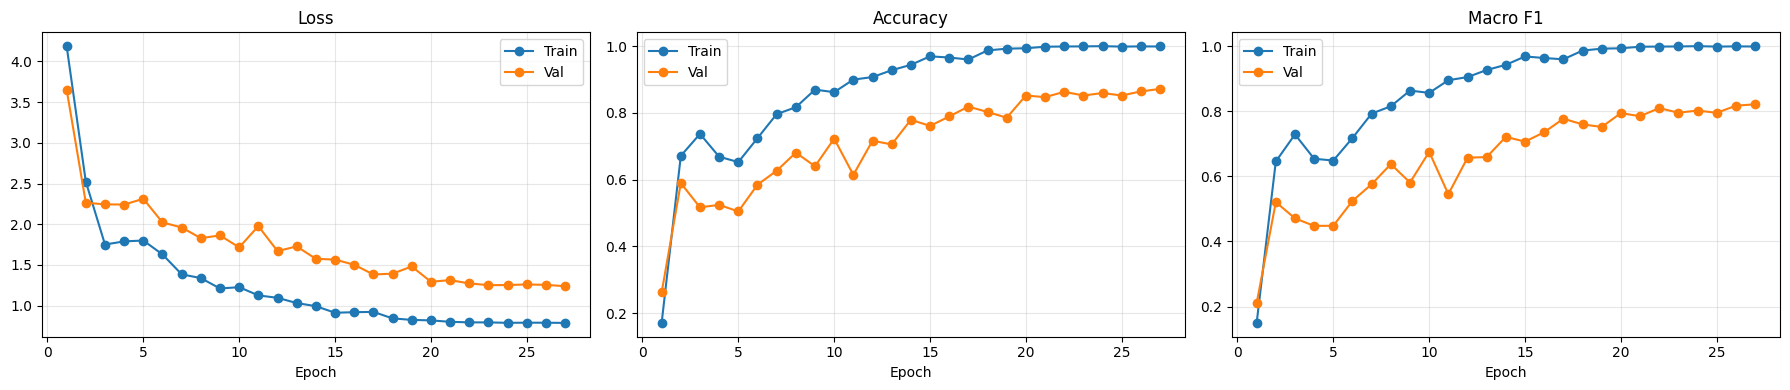

Best epoch by val macro F1: 27
Best val acc: 0.8719211822660099
Best val macro F1: 0.821374383619518


In [8]:
import matplotlib.pyplot as plt

history_to_plot = [] # Initialize history_to_plot
history_path = Path(MODEL_DIR) / "training_history.json"
with open(history_path, encoding="utf-8") as f:
    history_to_plot = json.load(f)

if not history_to_plot:
    print("No training history available to plot.")
else:
    epochs = [record["epoch"] for record in history_to_plot]
    train_loss = [record["train_loss"] for record in history_to_plot]
    val_loss = [record["val_loss"] for record in history_to_plot]
    train_acc = [record["train_acc"] for record in history_to_plot]
    val_acc = [record["val_acc"] for record in history_to_plot]
    train_f1 = [record["train_f1_macro"] for record in history_to_plot]
    val_f1 = [record["val_f1_macro"] for record in history_to_plot]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(epochs, train_loss, marker="o", label="Train")
    axes[0].plot(epochs, val_loss, marker="o", label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, train_acc, marker="o", label="Train")
    axes[1].plot(epochs, val_acc, marker="o", label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, train_f1, marker="o", label="Train")
    axes[2].plot(epochs, val_f1, marker="o", label="Val")
    axes[2].set_title("Macro F1")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = max(history_to_plot, key=lambda record: record["val_f1_macro"])
    print("Best epoch by val macro F1:", best_epoch["epoch"])
    print("Best val acc:", best_epoch["val_acc"])
    print("Best val macro F1:", best_epoch["val_f1_macro"])

## 7. Final Validation Report


In [9]:
best_model = VideoMAEForVideoClassification.from_pretrained(MODEL_DIR, num_labels=NUM_CLASSES).to(device)
model = best_model
if FP16 and device.type == "cuda":
    model.half()
model.eval()
final_metrics = evaluate()
print("Final val acc:", final_metrics["acc"])
print("Final val macro F1:", final_metrics["f1_macro"])
print(classification_report(final_metrics["labels"], final_metrics["preds"], target_names=class_names, zero_division=0))
print("Best model saved at:", MODEL_DIR)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

Val:   0%|          | 0/102 [00:00<?, ?it/s]

/tmp/ipykernel_8820/1247568087.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Final val acc: 0.8719211822660099
Final val macro F1: 0.821374383619518
                precision    recall  f1-score   support

        An ủi       0.75      1.00      0.86         6
     Áp dụng       0.93      0.82      0.88        17
           Ăn       1.00      0.75      0.86        12
    Ăn mừng       1.00      1.00      1.00        12
     Ban ngày       1.00      0.83      0.91         6
      Ban đêm       1.00      1.00      1.00         3
      Bàn tay       1.00      1.00      1.00         4
   Băn khoăn       0.92      1.00      0.96        12
    Bạn thân       1.00      0.80      0.89         5
     Bế mạc       1.00      1.00      1.00        10
  Bệnh nhân       0.00      0.00      0.00         1
 Bệnh viện       1.00      1.00      1.00        10
        Biết       1.00      0.93      0.97        15
 Biếu tặng       1.00      1.00      1.00        10
   Bộ y tế       1.00      1.00      1.00         3
           Cá       1.00      